https://www.nature.com/articles/nature20123

In [21]:
# Basic imports
import scanpy as sc

import sys, os

# Add parent directory to Python path
sys.path.append(os.path.abspath(".."))  

# Import pipeline functions

from scrna_pipeline import h5ad_builders, standard_scrna_pipeline, annotation

In [2]:
# Path to raw AnnData file (adjust as needed)
path = '/Users/alahi.irfan/Desktop/Local_workspace/Data/Tirosh_Nature_2016/GSE70630_OG_processed_data_v2.txt'

# Read the raw data
adata = h5ad_builders.expr_matrix_to_h5ad(path)

print(adata)
adata.obs.head()

📌 Loading RAW matrix: /Users/alahi.irfan/Desktop/Local_workspace/Data/Tirosh_Nature_2016/GSE70630_OG_processed_data_v2.txt
   Detected sep='\t' → Original shape: 23686 rows × 4347 cols
🔍 Using orientation: GENES are rows, CELLS are columns → transposing.
   Final matrix shape (cells × genes): (4347, 23686)
🔧 Stripped wrapping quotes from 23686 gene names.
✅ AnnData created: 4347 cells × 23686 genes
   → .X stores expression
   → .layers['expr'] stores a copy
💡 output_h5ad not provided → returning AnnData only.
AnnData object with n_obs × n_vars = 4347 × 23686
    layers: 'expr'


""
MGH36_P6_A12
MGH36_P6_H09
MGH53_P4_G04
MGH36_P10_G12
MGH53_P2_H12


In [8]:
print(adata.var_names[:5])
print(adata.obs_names[:5])



Index(['A1BG', 'A1BG-AS1', 'A1CF', 'A2M', 'A2M-AS1'], dtype='object')
Index(['MGH36_P6_A12', 'MGH36_P6_H09', 'MGH53_P4_G04', 'MGH36_P10_G12',
       'MGH53_P2_H12'],
      dtype='object')


In [9]:
import scanpy as sc

def qc_umap_minimal_processed(
    adata,
    *,
    n_top_genes: int = 2000,
    n_pcs: int = 30,
    random_state: int = 0,
):
    """
    Minimal QC UMAP for already-normalized / log-expression data
    (e.g., Smart-seq / Tirosh-style GEO matrices).

    Does NOT modify adata.
    """
    a = adata.copy()

    # HVGs directly on processed expression
    sc.pp.highly_variable_genes(
        a,
        n_top_genes=n_top_genes,
        flavor="seurat_v3"
    )

    a = a[:, a.var["highly_variable"]].copy()

    # Scaling is optional but helps PCA stability
    sc.pp.scale(a, max_value=10)

    sc.tl.pca(a, n_comps=n_pcs, svd_solver="arpack", random_state=random_state)
    sc.pp.neighbors(a, n_pcs=n_pcs, random_state=random_state)
    sc.tl.umap(a, random_state=random_state)

    sc.pl.umap(a)

    return a


/opt/miniconda3/envs/scrna-pipeline/lib/python3.10/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)
/opt/miniconda3/envs/scrna-pipeline/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/opt/miniconda3/envs/scrna-pipeline/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


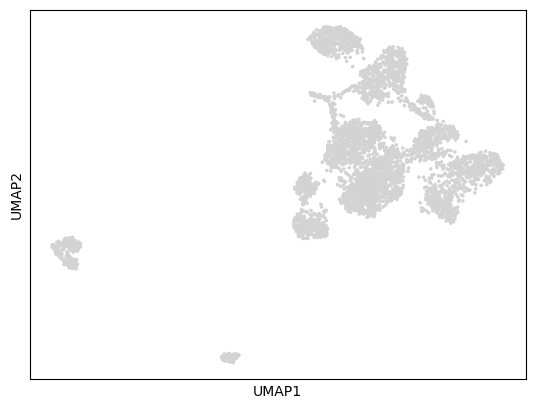

AnnData object with n_obs × n_vars = 4347 × 2000
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'hvg', 'pca', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'expr'
    obsp: 'distances', 'connectivities'

In [10]:
qc_umap_minimal_processed(adata)

In [15]:
import numpy as np
import scipy.sparse as sp
n_nan = np.isnan(adata.X.data).sum() if sp.issparse(adata.X) else np.isnan(adata.X).sum()
print("NaNs in X:", int(n_nan))

# Replace NaNs with 0 in-place
if sp.issparse(adata.X):
    adata.X.data = np.nan_to_num(adata.X.data, nan=0.0, posinf=0.0, neginf=0.0)
else:
    adata.X = np.nan_to_num(adata.X, nan=0.0, posinf=0.0, neginf=0.0)

NaNs in X: 21903


/var/folders/mr/gbhgcyxx2yz6w_nj9nmtr2nc0000gr/T/ipykernel_1620/4145386113.py:3: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata)


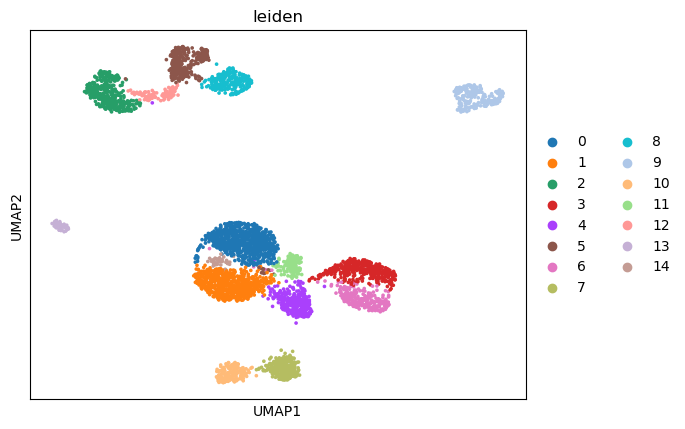

In [18]:
sc.tl.pca(adata)
sc.pp.neighbors(adata)
sc.tl.leiden(adata)
sc.tl.umap(adata)
sc.pl.umap(adata, color='leiden')

In [25]:
marker_dict = {
    "Epithelial": ["EPCAM", "KRT8", "KRT18", "KRT19"],
    "T_cell": ["CD3D", "CD3E", "CD2", "CD8A", "CD4"],
    "B_cell": ["MS4A1", "CD79A", "CD79B"],
    "Myeloid": ["LYZ", "CD68", "CD14", "TYROBP", "LST1", "CSF1R", "FCGR3A"],
    "Endothelial": ["PECAM1", "VWF", "KDR"],
    "Fibroblast": ["COL1A1", "COL1A2", "DCN"],
    "Mast": ["TPSAB1", "TPSB2", "CPA3"],
}


cluster_scores, suggested = annotation.score_markers_and_suggest_labels(adata, marker_dict, cluster_key= 'leiden')

/Users/alahi.irfan/Desktop/Local_workspace/scRNA-seq-pipeline/scrna_pipeline/annotation.py:148: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(cluster_key)[score_cols]


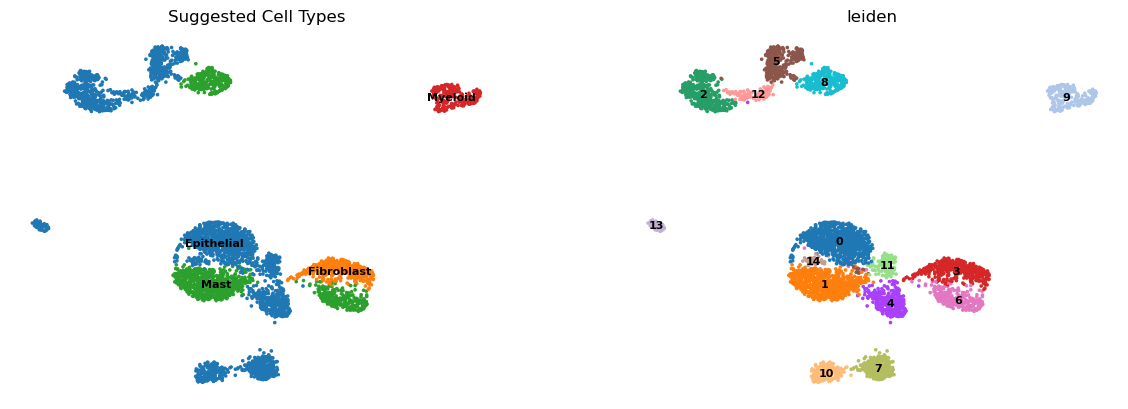

In [26]:
# Attach suggested labels for plotting
adata.obs["celltype"] = adata.obs['leiden'].map(suggested)


sc.pl.umap(
    adata,
    color=["celltype",'leiden'],
    legend_loc="on data",
    legend_fontsize=8,
    frameon=False,
    title="Suggested Cell Types",
)

# Infercnv

In [ ]:
from pathlib import Path
import urllib.request
import gzip, shutil

def _download_gencode_gtf(
    *,
    release: int = 44,
    cache_dir: str | Path = "~/.cache/genome/gtf",
    verbose: bool = True,
) -> Path:
    """
    Download and cache GENCODE human GTF (hg38).
    Returns path to uncompressed .gtf file.
    """
    cache_dir = Path(cache_dir).expanduser().resolve()
    cache_dir.mkdir(parents=True, exist_ok=True)

    gz_name = f"gencode.v{release}.annotation.gtf.gz"
    gtf_name = f"gencode.v{release}.annotation.gtf"

    gz_path = cache_dir / gz_name
    gtf_path = cache_dir / gtf_name

    url = (
        f"https://ftp.ebi.ac.uk/pub/databases/gencode/"
        f"Gencode_human/release_{release}/{gz_name}"
    )

    if gtf_path.exists():
        if verbose:
            print(f"[GTF] Using cached GTF: {gtf_path}")
        return gtf_path

    if verbose:
        print(f"[GTF] Downloading GENCODE v{release} from:\n{url}")

    urllib.request.urlretrieve(url, gz_path)

    if verbose:
        print(f"[GTF] Extracting {gz_path.name}")

    with gzip.open(gz_path, "rb") as f_in, open(gtf_path, "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)

    gz_path.unlink(missing_ok=True)

    if verbose:
        print(f"[GTF] Ready: {gtf_path}")

    return gtf_path


def add_gene_positions_from_gtf(
    adata,
    gtf_path: str | Path | None = None,
    *,
    gencode_release: int = 44,
    gene_symbol_key: str | None = None,
    make_var_unique: bool = True,
    cache_dir: str | Path = "~/.cache/genome/gtf",
    verbose: bool = True,
):
    """
    Add `chromosome`, `start`, `end` to adata.var.
    Automatically downloads GENCODE GTF if gtf_path is None.

    Parameters
    ----------
    adata : AnnData
    gtf_path : str or Path or None
        Path to GTF. If None, downloads GENCODE human GTF (hg38).
    gencode_release : int
        GENCODE release to download if gtf_path is None.
    gene_symbol_key : str, optional
        Column in adata.var containing gene symbols.
        If None, adata.var_names are used.
    cache_dir : str or Path
        Where to cache downloaded GTF.
    """
    if make_var_unique:
        adata.var_names_make_unique()

    # ---- get GTF path (download if needed) ----
    if gtf_path is None:
        gtf_path = _download_gencode_gtf(
            release=gencode_release,
            cache_dir=cache_dir,
            verbose=verbose,
        )
    else:
        gtf_path = Path(gtf_path).expanduser().resolve()

    if verbose:
        print(f"[add_gene_positions] Reading GTF: {gtf_path}")

    # ---- read minimal GTF ----
    cols = [
        "chromosome", "source", "feature",
        "start", "end", "score", "strand", "frame", "attribute"
    ]
    gtf = pd.read_csv(
        gtf_path,
        sep="\t",
        comment="#",
        header=None,
        names=cols,
        dtype={"chromosome": str},
    )

    gtf = gtf[gtf["feature"] == "gene"].copy()

    def _get_attr(attr: str, key: str):
        try:
            return attr.split(f'{key} "')[1].split('"')[0]
        except IndexError:
            return None

    gtf["gene_name"] = gtf["attribute"].apply(lambda x: _get_attr(x, "gene_name"))
    gtf["gene_id"] = gtf["attribute"].apply(lambda x: _get_attr(x, "gene_id"))

    gtf = gtf.dropna(subset=["gene_name"])
    gtf = gtf.sort_values(["gene_name", "start"]).drop_duplicates("gene_name")

    gene_pos = gtf.set_index("gene_name")[["chromosome", "start", "end"]]

    # ---- map to adata.var ----
    if gene_symbol_key is None:
        genes = pd.Index(adata.var_names.astype(str))
    else:
        if gene_symbol_key not in adata.var.columns:
            raise KeyError(f"{gene_symbol_key} not found in adata.var.columns")
        genes = pd.Index(adata.var[gene_symbol_key].astype(str))

    mapped = gene_pos.reindex(genes)

    adata.var["chromosome"] = mapped["chromosome"].values
    adata.var["start"] = mapped["start"].values
    adata.var["end"] = mapped["end"].values

    if verbose:
        missing = adata.var["chromosome"].isna().sum()
        print(
            f"[add_gene_positions] Positions added. "
            f"Missing genes: {missing}/{adata.n_vars}"
        )

    return adata



In [37]:
adata = add_gene_positions_from_gtf(adata)

[GTF] Downloading GENCODE v44 from:
https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_human/release_44/gencode.v44.annotation.gtf.gz


URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1017)>

In [28]:
%%time

import infercnvpy as cnv
cnv.tl.infercnv(
    adata,
    reference_key="cell_type",
    reference_cat=["Myeloid"],
    window_size=100,
    step=1,
)


ValueError: Genomic positions not found. There need to be `chromosome`, `start`, and `end` columns in `adata.var`. 